# Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [2]:
years = list(range(2000, 2025))
pdrb_values = [
    8543.758251, 8954.511696, 9419.397117, 9917.194781, 10448.55427,
    11021.70365, 11645.73708, 12309.82818, 13025.23639, 13788.93033,
    14616.50, 15515.80, 16423.20, 17318.50, 18201.10,
    19096.40, 20028.50, 21019.80, 22075.10, 23212.40,
    22596.50, 23466.80, 24535.10, 25740.22, 27015.50
]

# Buat DataFrame
df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df.set_index('Tahun', inplace=True)

print("Data PDRB ADHK (2000-2024) - Data Terbaru:")
print(df.round(2))
print(f"\nTotal {len(df)} tahun")


Data PDRB ADHK (2000-2024) - Data Terbaru:
           PDRB
Tahun          
2000    8543.76
2001    8954.51
2002    9419.40
2003    9917.19
2004   10448.55
2005   11021.70
2006   11645.74
2007   12309.83
2008   13025.24
2009   13788.93
2010   14616.50
2011   15515.80
2012   16423.20
2013   17318.50
2014   18201.10
2015   19096.40
2016   20028.50
2017   21019.80
2018   22075.10
2019   23212.40
2020   22596.50
2021   23466.80
2022   24535.10
2023   25740.22
2024   27015.50

Total 25 tahun


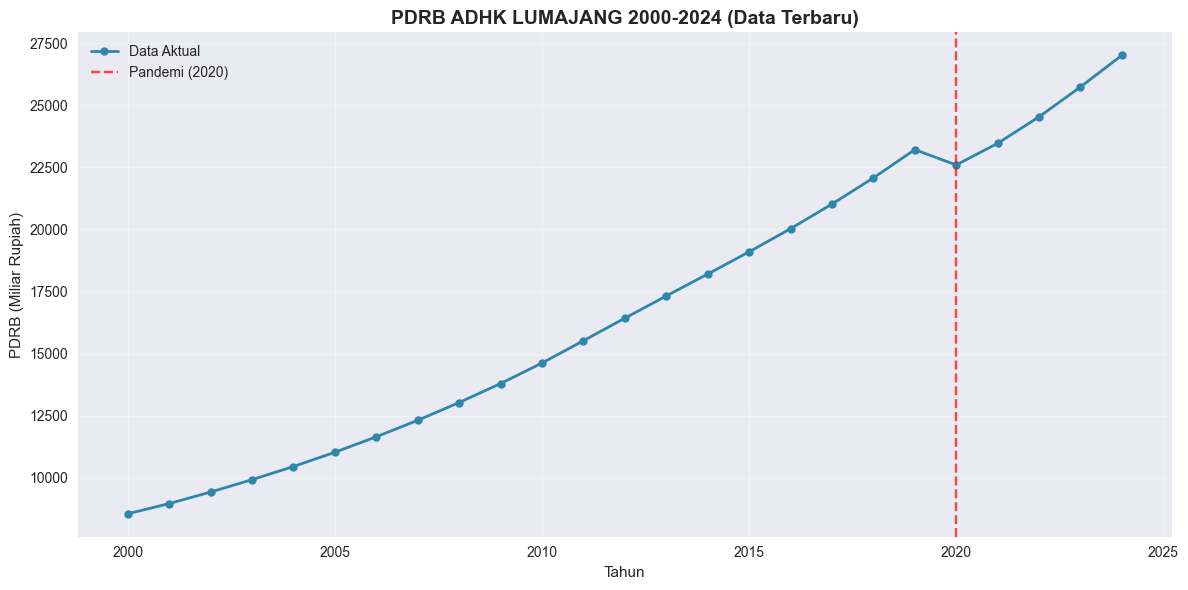

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['PDRB'], marker='o', linewidth=2, markersize=6, 
         color='#2E86AB', label='Data Aktual')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Pandemi (2020)')
plt.title('PDRB ADHK LUMAJANG 2000-2024 (Data Terbaru)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('PDRB (Miliar Rupiah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Data memiliki tren (non-stasioner)' if result[1] > 0.05 else 'Data stasioner')

ADF Statistic: 0.0692
p-value: 0.9639
Data memiliki tren (non-stasioner)


In [5]:
def calculate_mape(actual, forecast):
    """Hitung MAPE dengan handling nilai actual = 0"""
    actual, forecast = np.array(actual), np.array(forecast)
    mask = actual != 0
    if np.sum(mask) == 0:
        return np.nan
    mape = np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100
    return mape

In [ ]:
# Forecast 5 tahun
forecast_years = 5
forecast = fitted_model.forecast(forecast_years)

# Buat DataFrame forecast
forecast_index = list(range(2025, 2025 + forecast_years))
df_forecast = pd.DataFrame({
    'Tahun': forecast_index,
    'PDRB_Forecast': forecast.values
})
df_forecast.set_index('Tahun', inplace=True)

print("\nHasil Forecast PDRB 2025-2029:")
print(df_forecast.round(2))

# Hitung pertumbuhan tahunan dari 2025-2029
pdrb_2024 = df.loc[2024, 'PDRB']  
growth_2025 = ((df_forecast.iloc[0]['PDRB_Forecast'] - pdrb_2024) / pdrb_2024) * 100

# Pertumbuhan tahun-tahun berikutnya (2026-2029)
forecast_growth = df_forecast['PDRB_Forecast'].pct_change() * 100

print("\nPertumbuhan Tahunan Forecast 2025-2029:")
# Print pertumbuhan 2025
print(f"  {forecast_index[0]}: {growth_2025:.2f}%")

# Print pertumbuhan 2026-2029
for tahun, growth in zip(forecast_index[1:], forecast_growth[1:]):
    print(f"  {tahun}: {growth:.2f}%")

# Hitung rata-rata pertumbuhan 2025-2029
all_growth = [growth_2025] + list(forecast_growth[1:].values)
print(f"Rata-rata pertumbuhan 2025-2029: {np.mean(all_growth):.2f}%")


Hasil Forecast PDRB 2025-2029:
       PDRB_Forecast
Tahun               
2025        27960.58
2026        28905.65
2027        29850.73
2028        30795.80
2029        31740.88

Pertumbuhan Tahunan Forecast 2025-2029:
  2025: 3.50%
  2026: 3.38%
  2027: 3.27%
  2028: 3.17%
  2029: 3.07%
Rata-rata pertumbuhan 2025-2029: 3.28%


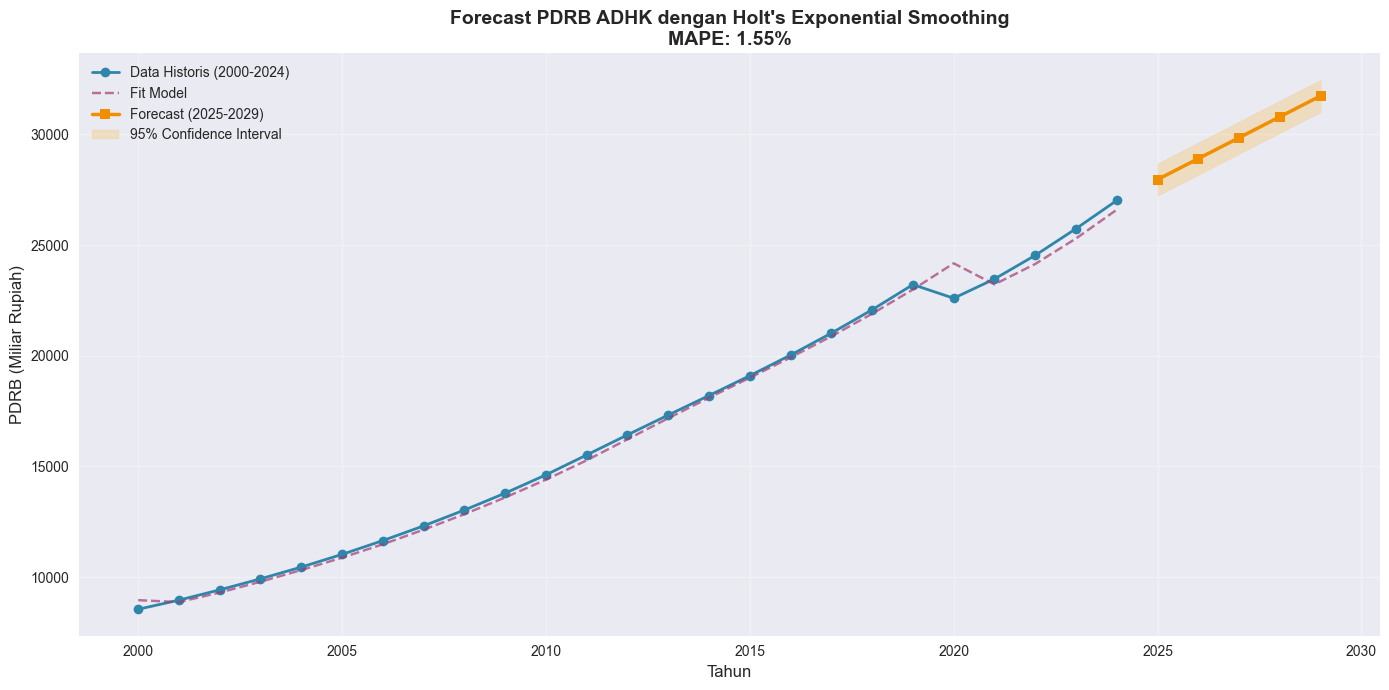

In [ ]:
# Estimasi confidence interval berdasarkan error historis
residuals = df['PDRB'] - fitted_model.fittedvalues
std_error = np.std(residuals)

plt.figure(figsize=(14, 7))

# Data historis
plt.plot(df.index, df['PDRB'], marker='o', label='Data Historis (2000-2024)', 
         linewidth=2, color='#2E86AB')

# Fit model
plt.plot(df.index, fitted_model.fittedvalues, linestyle='--', 
         label='Fit Model', color='#A23B72', alpha=0.7)

# Forecast
plt.plot(df_forecast.index, df_forecast['PDRB_Forecast'], marker='s', 
         label='Forecast (2025-2029)', linewidth=2.5, color='#F18F01')

# Confidence interval (±1.96 * std error)
plt.fill_between(
    df_forecast.index,
    df_forecast['PDRB_Forecast'] - 1.96 * std_error,
    df_forecast['PDRB_Forecast'] + 1.96 * std_error,
    color='orange', alpha=0.2, label='95% Confidence Interval'
)

plt.title(f'Forecast PDRB ADHK dengan Holt\'s Exponential Smoothing\n'
          f'MAPE: {mape_insample:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('PDRB (Miliar Rupiah)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Split data: 2000-2022 (train), 2023-2024 (test)
train = df.loc[:2022]
test = df.loc[2023:]

# Fit model pada data train
model_train = Holt(train['PDRB'], exponential=False).fit(optimized=True)

# Forecast untuk periode test
test_forecast = model_train.forecast(len(test))

# Hitung MAPE pada data test
mape_test = calculate_mape(test['PDRB'], test_forecast)

print("\nValidasi Model (Train-Test Split):")
print(f"Data Train: 2000-2022 ({len(train)} tahun)")
print(f"Data Test : 2023-2024 ({len(test)} tahun)")
print(f"MAPE pada Data Test: {mape_test:.2f}%")
print(f"Akurasi forecast 2 tahun terakhir: {100 - mape_test:.2f}%")

# Tampilkan perbandingan
comparison = pd.DataFrame({
    'Tahun': test.index,
    'Aktual': test['PDRB'].values,
    'Forecast': test_forecast.values,
    'Error (%)': np.abs((test['PDRB'].values - test_forecast.values) / test['PDRB'].values) * 100
})
print("\nPerbandingan Aktual vs Forecast (2023-2024):")
print(comparison.round(2))


Validasi Model (Train-Test Split):
Data Train: 2000-2022 (23 tahun)
Data Test : 2023-2024 (2 tahun)
MAPE pada Data Test: 2.92%
Akurasi forecast 2 tahun terakhir: 97.08%

Perbandingan Aktual vs Forecast (2023-2024):
   Tahun    Aktual  Forecast  Error (%)
0   2023  25740.22  25229.46       1.98
1   2024  27015.50  25972.45       3.86


# Log ARIMA

In [7]:
years = list(range(2000, 2025))
pdrb_values = [
    8543.758251, 8954.511696, 9419.397117, 9917.194781, 10448.55427,
    11021.70365, 11645.73708, 12309.82818, 13025.23639, 13788.93033,
    14616.50, 15515.80, 16423.20, 17318.50, 18201.10,
    19096.40, 20028.50, 21019.80, 22075.10, 23212.40,
    22596.50, 23466.80, 24535.10, 25740.22, 27015.50
]

df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df['Tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-12-31')
df = df.set_index('Tanggal')

print("Data PDRB ADHK (2000-2024) - Data Terbaru:")
print(df[['Tahun', 'PDRB']].round(2))
print(f"\nTotal data: {len(df)} tahun")

# 2. HITUNG PERSENTASE KENAIKAN TAHUNAN
df['Pertumbuhan (%)'] = df['PDRB'].pct_change() * 100

# Format kolom pertumbuhan dengan highlight negatif/positif
def format_growth(val):
    if pd.isna(val):
        return "-"
    elif val < 0:
        return f"▼ {val:.2f}%"
    else:
        return f"▲ {val:.2f}%"

print("Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:")
print("="*70)
print(f"{'Tahun':<8} {'PDRB (Miliar Rp)':<25} {'Pertumbuhan (%)':<20}")
print("="*70)

for idx, row in df.iterrows():
    tahun = row['Tahun']
    pdrb = f"Rp {row['PDRB']:,.2f}"
    growth = format_growth(row['Pertumbuhan (%)'])
    print(f"{tahun:<8} {pdrb:<25} {growth:<20}")

print("="*70)

Data PDRB ADHK (2000-2024) - Data Terbaru:
            Tahun      PDRB
Tanggal                    
2000-12-31   2000   8543.76
2001-12-31   2001   8954.51
2002-12-31   2002   9419.40
2003-12-31   2003   9917.19
2004-12-31   2004  10448.55
2005-12-31   2005  11021.70
2006-12-31   2006  11645.74
2007-12-31   2007  12309.83
2008-12-31   2008  13025.24
2009-12-31   2009  13788.93
2010-12-31   2010  14616.50
2011-12-31   2011  15515.80
2012-12-31   2012  16423.20
2013-12-31   2013  17318.50
2014-12-31   2014  18201.10
2015-12-31   2015  19096.40
2016-12-31   2016  20028.50
2017-12-31   2017  21019.80
2018-12-31   2018  22075.10
2019-12-31   2019  23212.40
2020-12-31   2020  22596.50
2021-12-31   2021  23466.80
2022-12-31   2022  24535.10
2023-12-31   2023  25740.22
2024-12-31   2024  27015.50

Total data: 25 tahun
Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:
Tahun    PDRB (Miliar Rp)          Pertumbuhan (%)     
2000.0   Rp 8,543.76               -                   
2001.0   Rp 

## Uji Stationer

In [8]:
print("\n" + "="*60)
print("UJI STASIONERITAS (ADF TEST)")
print("="*60)
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Kesimpulan: Data STASIONER' if result[1] < 0.05 else 'Kesimpulan: Data NON-STASIONER (perlu differencing)')



UJI STASIONERITAS (ADF TEST)
ADF Statistic: 0.0692
p-value: 0.9639
Kesimpulan: Data NON-STASIONER (perlu differencing)


### Diff 1

In [9]:
# 3. DIFFERENCING PERTAMA (d=1)
print("\n" + "="*60)
print("DIFFERENCING PERTAMA (d=1): Δy_t = y_t - y_{t-1}")
print("="*60)
df['PDRB_diff1'] = df['PDRB'].diff()

# Tampilkan contoh perhitungan differencing
print("\nContoh Perhitungan Differencing:")
print(f"  Δy_2001 = y_2001 - y_2000 = {df.loc['2001-12-31', 'PDRB']:.2f} - {df.loc['2000-12-31', 'PDRB']:.2f} = {df.loc['2001-12-31', 'PDRB_diff1']:.2f}")
print(f"  Δy_2020 = y_2020 - y_2019 = {df.loc['2020-12-31', 'PDRB']:.2f} - {df.loc['2019-12-31', 'PDRB']:.2f} = {df.loc['2020-12-31', 'PDRB_diff1']:.2f} (kontraksi pandemi)")

# 4. UJI STASIONERITAS SETELAH DIFFERENCING PERTAMA
result_diff1 = adfuller(df['PDRB_diff1'].dropna())
print("\n" + "="*60)
print("UJI STASIONERITAS - SETELAH DIFFERENCING PERTAMA")
print("="*60)
print(f"ADF Statistic: {result_diff1[0]:.4f}")
print(f"p-value      : {result_diff1[1]:.4f}")
print(f"Kesimpulan   : {'STASIONER' if result_diff1[1] < 0.05 else 'MASIH NON-STASIONER (perlu differencing kedua)'}")



DIFFERENCING PERTAMA (d=1): Δy_t = y_t - y_{t-1}

Contoh Perhitungan Differencing:
  Δy_2001 = y_2001 - y_2000 = 8954.51 - 8543.76 = 410.75
  Δy_2020 = y_2020 - y_2019 = 22596.50 - 23212.40 = -615.90 (kontraksi pandemi)

UJI STASIONERITAS - SETELAH DIFFERENCING PERTAMA
ADF Statistic: -2.9292
p-value      : 0.0421
Kesimpulan   : STASIONER


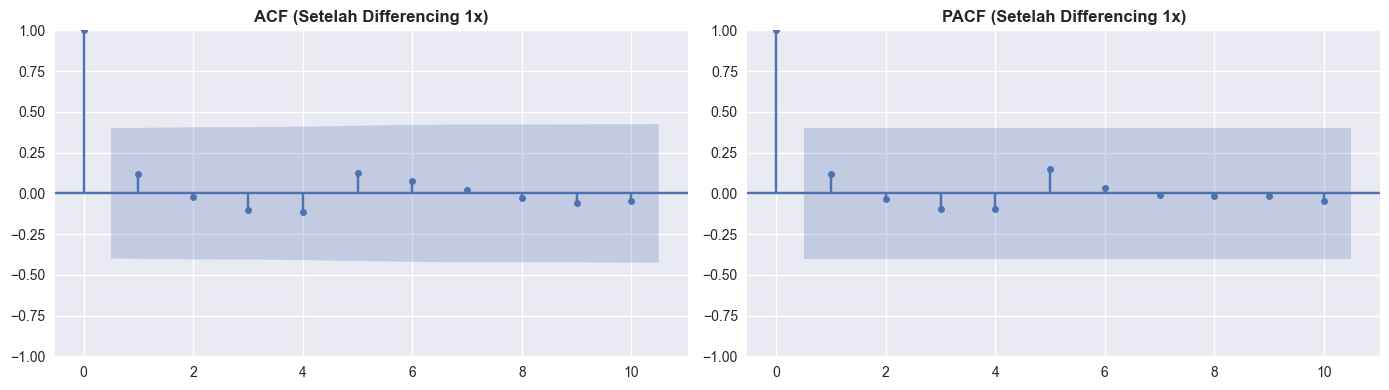

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['PDRB_diff1'].dropna(), ax=axes[0], lags=10)
plot_pacf(df['PDRB_diff1'].dropna(), ax=axes[1], lags=10)
axes[0].set_title('ACF (Setelah Differencing 1x)', fontsize=12, fontweight='bold')
axes[1].set_title('PACF (Setelah Differencing 1x)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


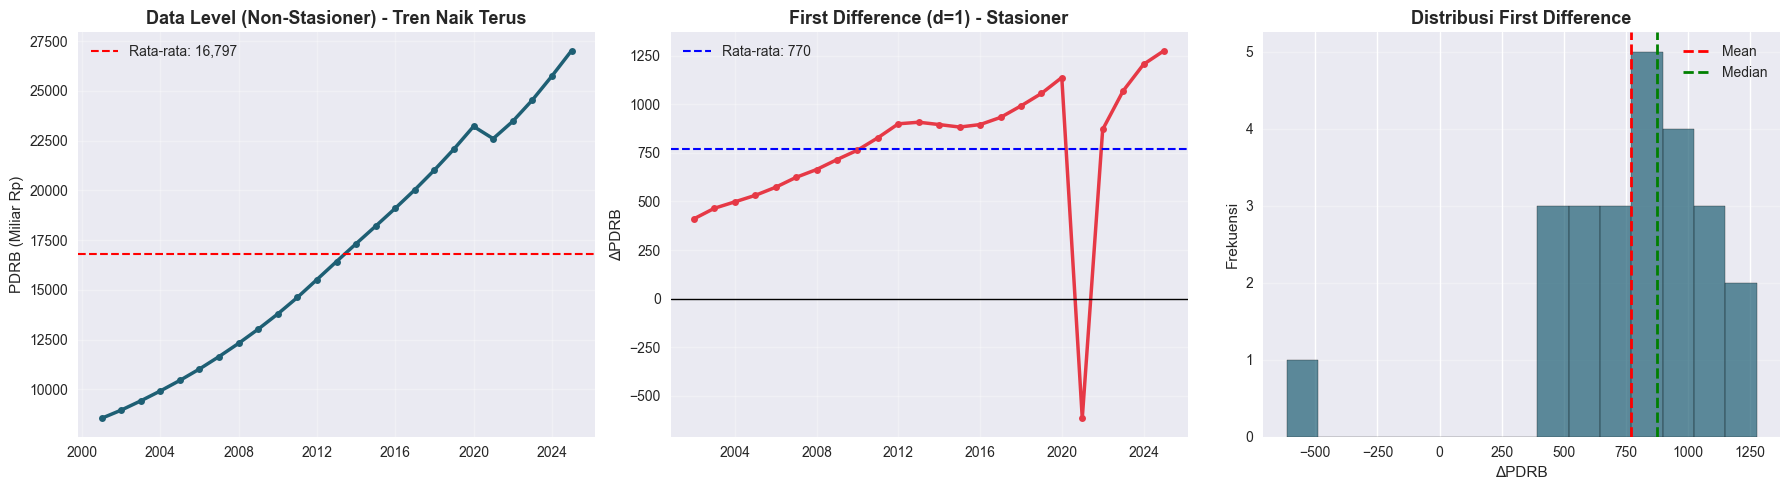

<Figure size 800x550 with 0 Axes>

In [11]:
# Buat figure dengan 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Data Level (Non-Stasioner)
axes[0].plot(df.index, df['PDRB'], color='#1E5F74', linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Data Level (Non-Stasioner) - Tren Naik Terus', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PDRB (Miliar Rp)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=df['PDRB'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Rata-rata: {df["PDRB"].mean():,.0f}')
axes[0].legend()

# Plot 2: First Difference (Stasioner)
axes[1].plot(df.index, df['PDRB_diff1'], color='#E63946', linewidth=2.5, marker='o', markersize=5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.0)
axes[1].axhline(y=df['PDRB_diff1'].mean(), color='blue', linestyle='--', linewidth=1.5, 
                label=f'Rata-rata: {df["PDRB_diff1"].mean():,.0f}')
axes[1].set_title('First Difference (d=1) - Stasioner', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ΔPDRB', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Histogram Distribusi
axes[2].hist(df['PDRB_diff1'].dropna(), bins=15, color='#1E5F74', edgecolor='black', alpha=0.7)
axes[2].axvline(df['PDRB_diff1'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[2].axvline(df['PDRB_diff1'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[2].set_title('Distribusi First Difference', fontsize=13, fontweight='bold')
axes[2].set_xlabel('ΔPDRB', fontsize=11)
axes[2].set_ylabel('Frekuensi', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

plt.suptitle('Proses Differencing untuk Mencapai Stasioneritas\n'
            f'Data Asli: p-value={result[1]:.4f} (Non-Stasioner) → '
            f'Setelah d=1: p-value={result_diff1[1]:.4f} ({"Stasioner" if result_diff1[1] < 0.05 else "Non-Stasioner"})',
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [12]:
# 7. INTEGRASI DENGAN MODEL ARIMA
print("\n" + "="*60)
print("PENERAPAN PADA MODEL ARIMA")
print("="*60)
print("Untuk data PDRB Jember:")
print(f"  • Data level      : Non-stasioner (p-value = {result[1]:.4f})")
print(f"  • Setelah d=1     : {'Stasioner' if result_diff1[1] < 0.05 else 'Non-stasioner'} (p-value = {result_diff1[1]:.4f})")

if result_diff1[1] < 0.05:
    print("\n✓ Rekomendasi Model: ARIMA(p, 1, q)")
    print("  Contoh: ARIMA(0,1,1) + Drift seperti yang telah digunakan")
    print("\nPenjelasan Matematis:")
    print("  Model ARIMA(0,1,1) pada data level = Model MA(1) pada data differenced:")
    print("    Δy_t = c + ε_t + θ·ε_{t-1}")
    print("  di mana:")
    print("    • Δy_t = y_t - y_{t-1} (first difference)")
    print("    • c    = drift (pertumbuhan rata-rata)")
    print("    • θ    = koefisien MA(1)")
else:
    print("\n⚠ Rekomendasi Model: ARIMA(p, 2, q) - Differencing kedua diperlukan")
    print("  Namun untuk data ekonomi, d=2 jarang digunakan karena menghilangkan informasi tren")


PENERAPAN PADA MODEL ARIMA
Untuk data PDRB Jember:
  • Data level      : Non-stasioner (p-value = 0.9639)
  • Setelah d=1     : Stasioner (p-value = 0.0421)

✓ Rekomendasi Model: ARIMA(p, 1, q)
  Contoh: ARIMA(0,1,1) + Drift seperti yang telah digunakan

Penjelasan Matematis:
  Model ARIMA(0,1,1) pada data level = Model MA(1) pada data differenced:
    Δy_t = c + ε_t + θ·ε_{t-1}
  di mana:
    • Δy_t = y_t - y_{t-1} (first difference)
    • c    = drift (pertumbuhan rata-rata)
    • θ    = koefisien MA(1)


## Splitting

In [13]:
train = df.loc[:'2020-12-31']
test = df.loc['2021-12-31':]

print("\n" + "="*60)
print("SPLIT DATA (VALIDASI DIPERLUAS)")
print("="*60)
print(f"Data Train: {train.index.min().year} - {train.index.max().year} ({len(train)} tahun)")
print(f"Data Test : {test.index.min().year} - {test.index.max().year} ({len(test)} tahun)")
print("Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)")


SPLIT DATA (VALIDASI DIPERLUAS)
Data Train: 2000 - 2020 (21 tahun)
Data Test : 2021 - 2024 (4 tahun)
Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)


## Log Transformasi

In [14]:
# 4. LOG-TRANSFORMASI (Pra-pemrosesan untuk Log-ARIMA)
print("\n" + "="*70)
print("LOG-TRANSFORMASI DATA")
print("="*70)
train_log = np.log(train['PDRB'])
test_log = np.log(test['PDRB'])


LOG-TRANSFORMASI DATA


## Fit Model

In [15]:
#FIT MODEL LOG-ARIMA(0,1,1) + DRIFT
print("="*70)
print("FIT MODEL LOG-ARIMA(0,1,1) + DRIFT")
print("="*70)

model_log = ARIMA(train_log, order=(0, 1, 1), trend='t')
fitted_log = model_log.fit()



FIT MODEL LOG-ARIMA(0,1,1) + DRIFT


In [16]:
#Tampilkan parameter model
print(f"\nParameter Model (Skala Log):")
drift_param = fitted_log.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f}")
print(f"  MA(1) Coef (θ)  : {fitted_log.params['ma.L1']:.6f}")
print(f"  Variance (σ²)   : {fitted_log.params['sigma2']:.6f}")
print(f"\nInterpretasi Drift:")
print(f"  c = {drift_param:.6f} → Pertumbuhan rata-rata {(np.exp(drift_param) - 1)*100:.2f}%/tahun")

# 7. VALIDASI PADA DATA TEST (2021-2024)
print("\n" + "="*70)
print("VALIDASI MODEL PADA DATA TEST (2021-2024)")
print("="*70)


Parameter Model (Skala Log):
  Drift (c)       : nan
  MA(1) Coef (θ)  : 0.406103
  Variance (σ²)   : 0.000303

Interpretasi Drift:
  c = nan → Pertumbuhan rata-rata nan%/tahun

VALIDASI MODEL PADA DATA TEST (2021-2024)


## Forecast Skala Log

In [17]:
# Forecast pada skala log
forecast_log = fitted_log.forecast(steps=len(test))

# Back-transform ke skala asli (tanpa koreksi bias untuk simplicity)
forecast_original = np.exp(forecast_log)

## MAPE Testing

In [18]:
# Hitung MAPE
def calculate_mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

mape_test = calculate_mape(test['PDRB'], forecast_original)
print(f"MAPE pada Data Test (2021-2024): {mape_test:.3f}%")

MAPE pada Data Test (2021-2024): 1.981%


In [19]:
# Tampilkan perbandingan detail
comparison = pd.DataFrame({
    'Tahun': test['Tahun'].values,
    'Aktual': test['PDRB'].values,
    'Forecast': forecast_original.values,
    'Error (%)': np.abs((test['PDRB'].values - forecast_original.values) / test['PDRB'].values) * 100
})
print("\nPerbandingan Detail Aktual vs Forecast:")
print(comparison.round(2).to_string(index=False))

#Analisis error per tahun
print("\nAnalisis Error:")
for idx, row in comparison.iterrows():
    status = "✓" if row['Error (%)'] < 2 else "⚠"
    print(f"  {status} {int(row['Tahun'])}: Error {row['Error (%)']:.2f}%")



Perbandingan Detail Aktual vs Forecast:
 Tahun   Aktual  Forecast  Error (%)
  2021 23466.80  22975.16       2.10
  2022 24535.10  24082.72       1.84
  2023 25740.22  25243.67       1.93
  2024 27015.50  26460.58       2.05

Analisis Error:
  ⚠ 2021: Error 2.10%
  ✓ 2022: Error 1.84%
  ✓ 2023: Error 1.93%
  ⚠ 2024: Error 2.05%


## Fit Model Final

In [20]:
# 8. FIT MODEL FINAL PADA SELURUH DATA (2000-2024)
print("\n" + "="*70)
print("MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)")
print("="*70)

full_log = np.log(df['PDRB'])
model_full = ARIMA(full_log, order=(0, 1, 1), trend='t')
fitted_full = model_full.fit()

print(f"Parameter Final:")
drift_param = fitted_full.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f} → {(np.exp(drift_param) - 1)*100:.2f}%/tahun")
print(f"  MA(1) Coef (θ)  : {fitted_full.params['ma.L1']:.6f}")
print(f"  AIC             : {fitted_full.aic:.2f}")
print(f"  BIC             : {fitted_full.bic:.2f}")



MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)
Parameter Final:
  Drift (c)       : nan → nan%/tahun
  MA(1) Coef (θ)  : 0.179949
  AIC             : -124.17
  BIC             : -120.63


In [21]:
# 9. FORECAST 4 TAHUN KE DEPAN (2025-2028)
print("\n" + "="*70)
print("FORECAST 4 TAHUN KE DEPAN (2025-2028)")
print("="*70)

forecast_steps = 4
forecast_log_full = fitted_full.get_forecast(steps=forecast_steps)
forecast_mean_log = forecast_log_full.predicted_mean
forecast_ci_log = forecast_log_full.conf_int(alpha=0.05)
forecast_mean = np.exp(forecast_mean_log)
forecast_ci_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_ci_upper = np.exp(forecast_ci_log.iloc[:, 1])

forecast_years = [2025, 2026, 2027, 2028]
df_forecast = pd.DataFrame({
    'Tahun': forecast_years,
    'PDRB_Forecast': forecast_mean.values,
    'Lower_95%': forecast_ci_lower.values,
    'Upper_95%': forecast_ci_upper.values
})



FORECAST 4 TAHUN KE DEPAN (2025-2028)


## Hasil Forecast

In [22]:
print(df_forecast.round(2).to_string(index=False))

 Tahun  PDRB_Forecast  Lower_95%  Upper_95%
  2025       28344.02   27465.79   29250.33
  2026       29736.44   28323.48   31219.88
  2027       31197.25   29344.33   33167.18
  2028       32729.83   30467.89   35159.70


In [23]:
print("\n" + "="*70)
print("PERTUMBUHAN TAHUNAN FORECAST (2025-2028)")
print("="*70)

# Pertumbuhan 2025 (dari 2024 historis ke 2025 forecast)
growth_2025 = ((df_forecast.loc[0, 'PDRB_Forecast'] - df.loc['2024-12-31', 'PDRB']) / df.loc['2024-12-31', 'PDRB']) * 100
print(f"  2025: +{growth_2025:.2f}% (dari 2024 → 2025)")

# Pertumbuhan 2026-2028
forecast_growth = []
for i in range(1, len(df_forecast)):
    growth = ((df_forecast.loc[i, 'PDRB_Forecast'] - df_forecast.loc[i-1, 'PDRB_Forecast']) / df_forecast.loc[i-1, 'PDRB_Forecast']) * 100
    forecast_growth.append(growth)
    print(f"  {forecast_years[i]}: +{growth:.2f}% (dari {forecast_years[i-1]} → {forecast_years[i]})")



PERTUMBUHAN TAHUNAN FORECAST (2025-2028)
  2025: +4.92% (dari 2024 → 2025)
  2026: +4.91% (dari 2025 → 2026)
  2027: +4.91% (dari 2026 → 2027)
  2028: +4.91% (dari 2027 → 2028)


## Visualisasi

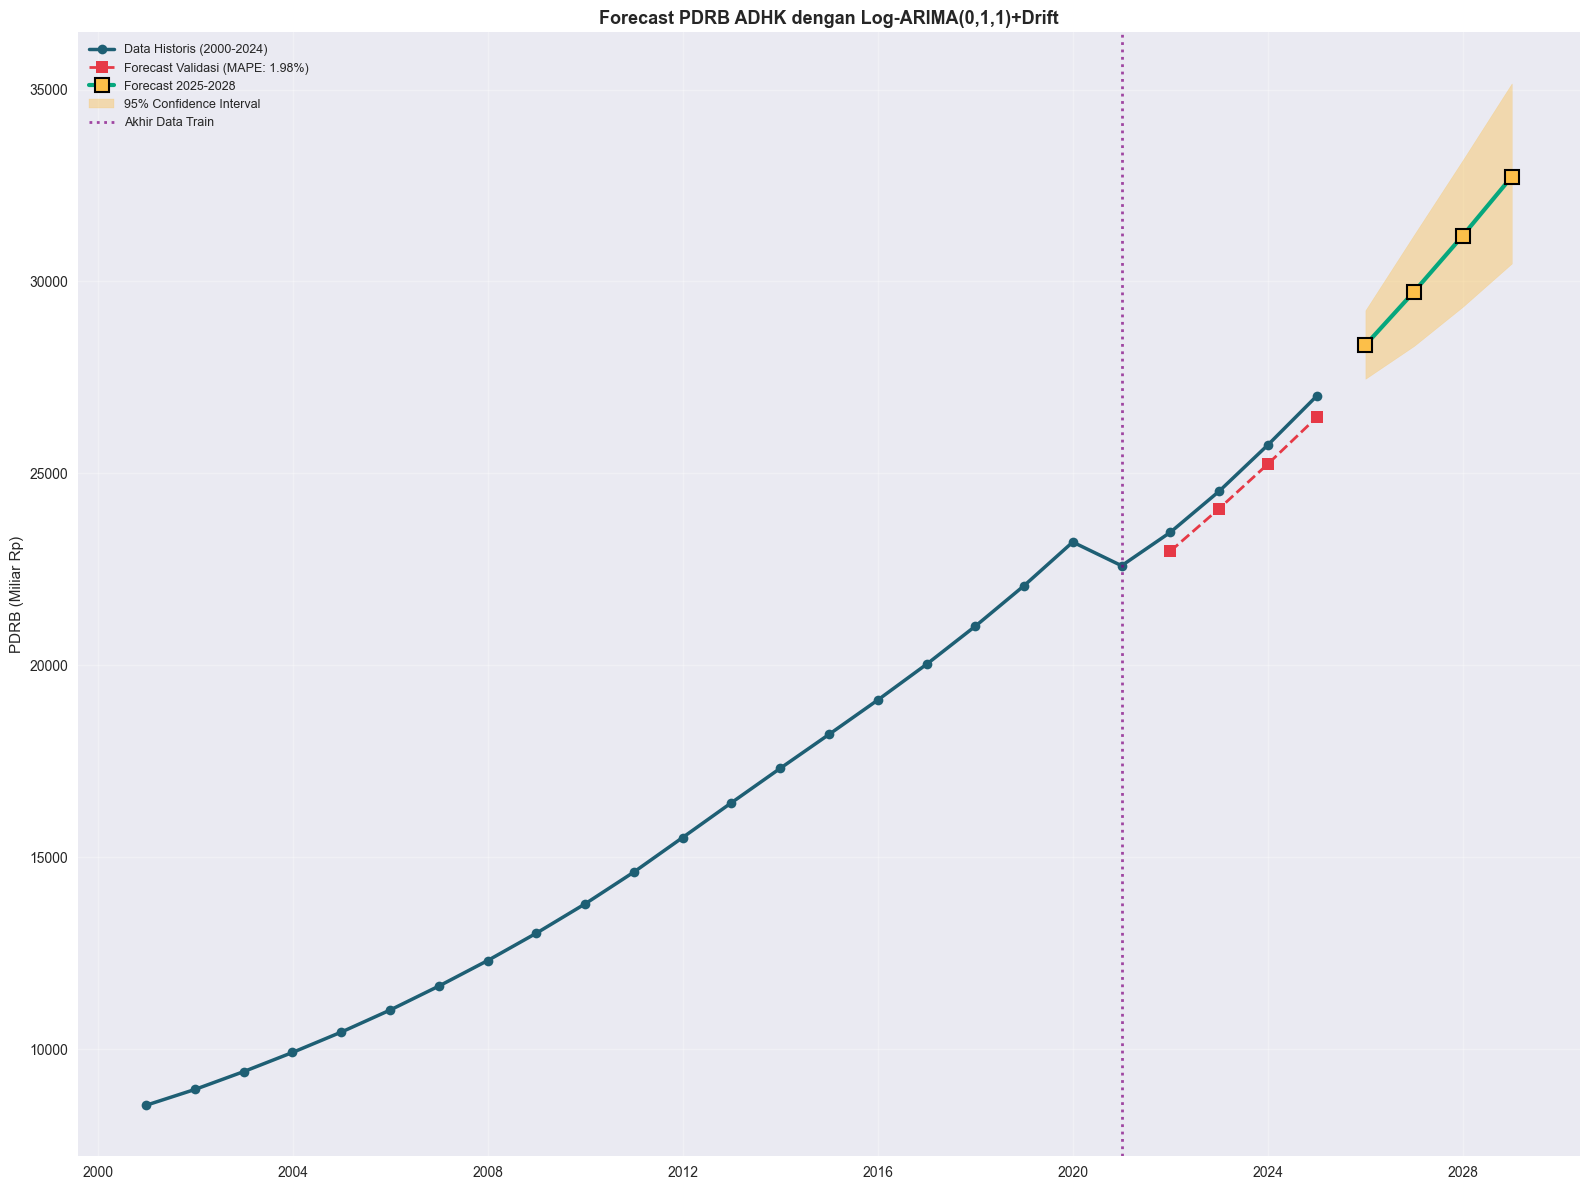

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(16, 12))
# Plot 1: Data Historis + Forecast
axes.plot(df.index, df['PDRB'], 'o-', label='Data Historis (2000-2024)', 
          linewidth=2.5, markersize=7, color='#1E5F74')
axes.plot(test.index, forecast_original, 's--', label=f'Forecast Validasi (MAPE: {mape_test:.2f}%)', 
          linewidth=2, markersize=8, color='#E63946')
axes.plot(pd.date_range('2025-12-31', periods=4, freq='YE'), 
          forecast_mean, 's-', label='Forecast 2025-2028', 
          linewidth=3, markersize=10, color='#06A77D', 
          markerfacecolor='#FCBF49', markeredgecolor='black', markeredgewidth=1.5)
axes.fill_between(pd.date_range('2025-12-31', periods=4, freq='YE'),
                  forecast_ci_lower, forecast_ci_upper, 
                  color='#FCBF49', alpha=0.4, label='95% Confidence Interval')
axes.axvline(x=pd.Timestamp('2020-12-31'), color='purple', linestyle=':', 
             linewidth=2, alpha=0.7, label='Akhir Data Train')
axes.set_title('Forecast PDRB ADHK dengan Log-ARIMA(0,1,1)+Drift', 
               fontsize=13, fontweight='bold')
axes.set_ylabel('PDRB (Miliar Rp)', fontsize=11)
axes.legend(fontsize=9, loc='upper left')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
